In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [4]:
# Auto-detect date and network from available kernel files
def _parse_kernel_stem(path):
    stem = os.path.basename(path).replace('.npz', '')
    date = stem[:10]
    network = stem[11:].split('_kernel_alpha_')[0]
    return date, network

_all_kernel = glob.glob('Files/vacc/*_kernel_alpha_*.npz')
if not _all_kernel:
    raise FileNotFoundError("No kernel sweep files found in Files/vacc/")

DATE, NETWORK = sorted(set(_parse_kernel_stem(f) for f in _all_kernel))[-1]

# Load kernel files for this date/network, sorted by alpha
files = sorted(
    glob.glob(f'Files/vacc/{DATE}_{NETWORK}_kernel_alpha_*.npz'),
    key=lambda f: float(np.load(f)['alpha'])
)

runs = []
for f in files:
    d = np.load(f)
    runs.append({
        'alpha': float(d['alpha']),
        'delta': d['delta'],
        'I_low': d['I_low'],
        'I_high': d['I_high'],
        'lam': d['lam_grid'],
        'nu': d['nu_grid'],
    })

baseline_path = f'Files/vacc/{DATE}_{NETWORK}_baseline.npz'
has_baseline = os.path.exists(baseline_path)
if has_baseline:
    bd = np.load(baseline_path)

print(f'Date: {DATE}  Network: {NETWORK}')
print(f'Loaded {len(runs)} kernel files' + (' + baseline' if has_baseline else ' (no baseline yet)'))
for r in runs:
    n_bi = int((r['delta'] > 0.05).sum())
    print(f'  alpha={r["alpha"]:5.1f}  max_delta={r["delta"].max():.4f}  bistable_cells(>0.05)={n_bi}')

Date: 2026-05-02  Network: Thiers13
Loaded 5 kernel files + baseline
  alpha=  0.1  max_delta=0.2450  bistable_cells(>0.05)=253
  alpha=  0.5  max_delta=0.2654  bistable_cells(>0.05)=274
  alpha=  1.0  max_delta=0.2602  bistable_cells(>0.05)=285
  alpha=  2.0  max_delta=0.2437  bistable_cells(>0.05)=289
  alpha=  5.0  max_delta=0.2207  bistable_cells(>0.05)=275


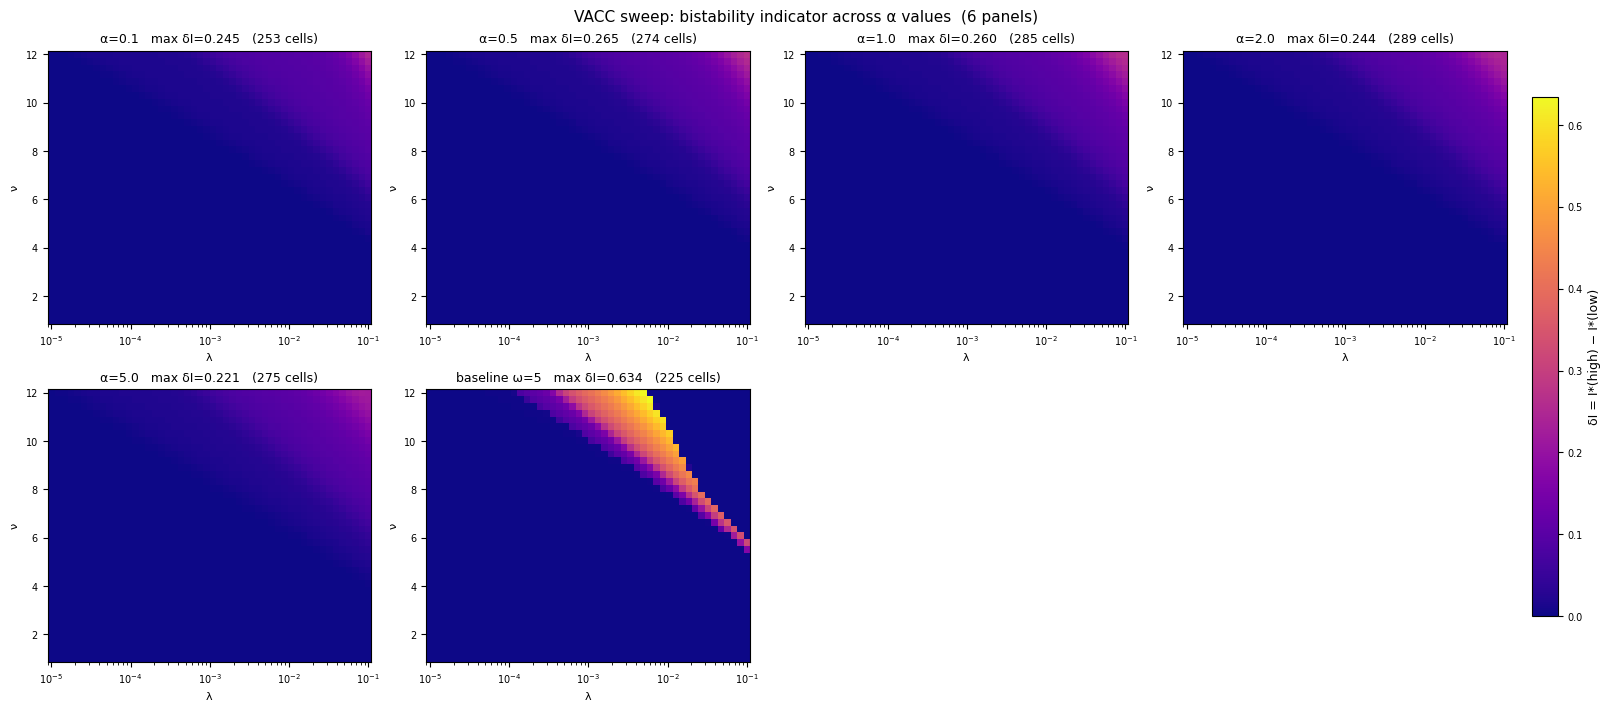

Saved → figures/2026-05-02_Thiers13_vacc_sweep_alpha_grid.png


In [5]:
# --- Alpha-grid heatmap ---
# One panel per alpha value, baseline appended if available.
# Color scale shared across all panels.

n_panels = len(runs) + (1 if has_baseline else 0)
ncols = 4
nrows = (n_panels + ncols - 1) // ncols

vmax = max(r['delta'].max() for r in runs)
if has_baseline:
    vmax = max(vmax, float(bd['delta'].max()))

# constrained_layout handles colorbar spacing automatically — do not call tight_layout()
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                               constrained_layout=True)
axes = axes_grid.flatten()

last_im = None
for idx, run in enumerate(runs):
    ax = axes[idx]
    delta = run['delta'].T   # (N_NU, N_LAM)
    lam, nu = run['lam'], run['nu']
    im = ax.pcolormesh(
        lam, nu, delta,
        vmin=0, vmax=vmax, cmap='plasma', shading='auto'
    )
    ax.set_xscale('log')
    last_im = im
    n_bi = int((run['delta'] > 0.05).sum())
    ax.set_title(f'α={run["alpha"]:.1f}   max δI={run["delta"].max():.3f}   ({n_bi} cells)', fontsize=9)
    ax.set_xlabel('λ', fontsize=8)
    ax.set_ylabel('ν', fontsize=8)
    ax.tick_params(labelsize=7)

if has_baseline:
    ax = axes[len(runs)]
    delta_b = bd['delta'].T
    lam_b, nu_b = bd['lam_grid'], bd['nu_grid']
    im = ax.pcolormesh(
        lam_b, nu_b, delta_b,
        vmin=0, vmax=vmax, cmap='plasma', shading='auto'
    )
    ax.set_xscale('log')
    last_im = im
    n_bi_b = int((bd['delta'] > 0.05).sum())
    ax.set_title(f'baseline ω=5   max δI={float(bd["delta"].max()):.3f}   ({n_bi_b} cells)', fontsize=9)
    ax.set_xlabel('λ', fontsize=8)
    ax.set_ylabel('ν', fontsize=8)
    ax.tick_params(labelsize=7)

for idx in range(n_panels, len(axes)):
    axes[idx].set_visible(False)

# Anchor to rightmost column (2D slice) — constrained_layout reserves the space correctly
cbar = fig.colorbar(last_im, ax=axes_grid[:, -1].tolist(), shrink=0.85)
cbar.set_label('δI = I*(high) − I*(low)', fontsize=9)
cbar.ax.tick_params(labelsize=7)

fig.suptitle(f'VACC sweep: bistability indicator across α values  ({n_panels} panels)', fontsize=11)
outpath = f'figures/{DATE}_{NETWORK}_vacc_sweep_alpha_grid.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {outpath}')

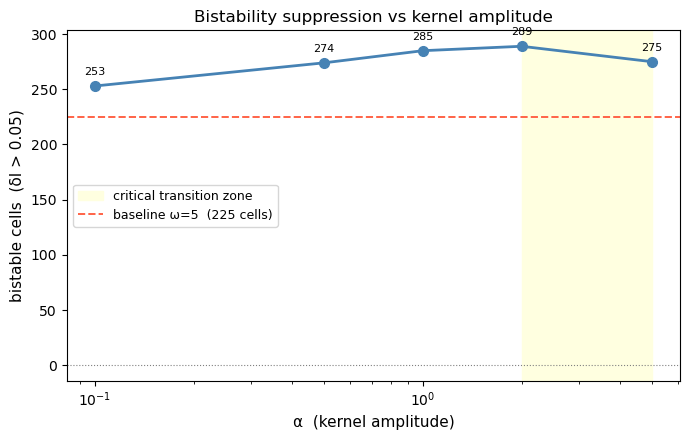

Saved → figures/2026-05-02_Thiers13_bistable_count_vs_alpha.png


In [6]:
# --- Bistable-cell count vs alpha ---
# Shows how many (lambda, nu) cells have delta > 0.05 as alpha varies.

alphas = [r['alpha'] for r in runs]
counts = [int((r['delta'] > 0.05).sum()) for r in runs]

fig, ax = plt.subplots(figsize=(7, 4.5))

# Shade the critical suppression zone (alpha=2 → alpha=5)
ax.axvspan(2, 5, color='lightyellow', zorder=0, label='critical transition zone')

# Baseline reference
if has_baseline:
    n_bi_b = int((bd['delta'] > 0.05).sum())
    ax.axhline(n_bi_b, color='tomato', linestyle='--', linewidth=1.4,
               label=f'baseline ω=5  ({n_bi_b} cells)', zorder=1)

ax.plot(alphas, counts, 'o-', color='steelblue', linewidth=2, markersize=7, zorder=2)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, zorder=1)

for a, c in zip(alphas, counts):
    ax.annotate(str(c), (a, c), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)

ax.set_xlabel('α  (kernel amplitude)', fontsize=11)
ax.set_ylabel('bistable cells  (δI > 0.05)', fontsize=11)
ax.set_title('Bistability suppression vs kernel amplitude', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=9, framealpha=0.8)
plt.tight_layout()
outpath = f'figures/{DATE}_{NETWORK}_bistable_count_vs_alpha.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {outpath}')

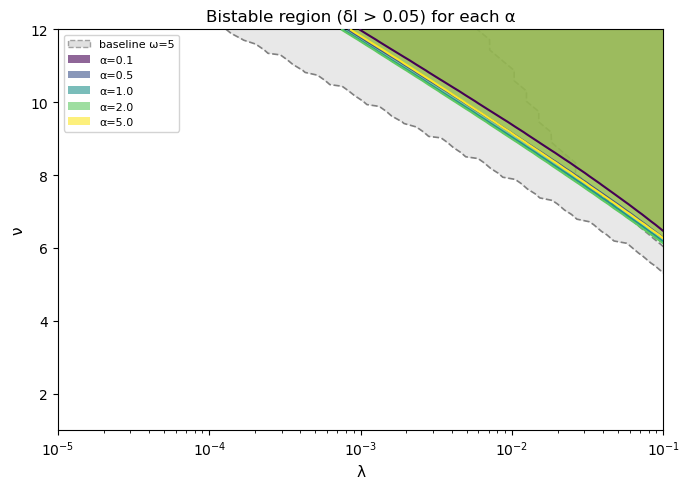

Saved → figures/2026-05-02_Thiers13_bistable_region_overlay.png


In [7]:
# --- Where does bistability sit in (lambda, nu) space? ---
# Overlay contours of delta > 0.05 for each alpha on a single plot.
# Useful for seeing whether the bistable region shifts as alpha changes.

from matplotlib.patches import Patch

bistable_runs = [r for r in runs if r['delta'].max() > 0.05]
cmap_k = plt.cm.viridis
colors = [cmap_k(i / max(len(bistable_runs) - 1, 1)) for i in range(len(bistable_runs))]

fig, ax = plt.subplots(figsize=(7, 5))

# Baseline footprint first (background reference)
if has_baseline:
    delta_b = bd['delta'].T
    lam_b, nu_b = bd['lam_grid'], bd['nu_grid']
    ax.contourf(lam_b, nu_b, delta_b,
                levels=[0.05, delta_b.max() + 0.01],
                colors=['lightgray'], alpha=0.5, zorder=0)
    ax.contour(lam_b, nu_b, delta_b,
               levels=[0.05], colors=['gray'], linewidths=1.2,
               linestyles='--', zorder=1)

for run, color in zip(bistable_runs, colors):
    lam, nu = run['lam'], run['nu']
    delta = run['delta'].T
    ax.contourf(lam, nu, delta,
                levels=[0.05, delta.max() + 0.01],
                colors=[color], alpha=0.4, zorder=2)
    ax.contour(lam, nu, delta,
               levels=[0.05], colors=[color], linewidths=1.5, zorder=3)

handles = [Patch(facecolor='lightgray', edgecolor='gray', linestyle='--',
                 alpha=0.7, label='baseline ω=5')]
handles += [
    Patch(facecolor=colors[i], alpha=0.6, label=f'α={bistable_runs[i]["alpha"]:.1f}')
    for i in range(len(bistable_runs))
]
ax.legend(handles=handles, fontsize=8, loc='upper left', framealpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('λ', fontsize=11)
ax.set_ylabel('ν', fontsize=11)
ax.set_title('Bistable region (δI > 0.05) for each α', fontsize=12)
plt.tight_layout()
outpath = f'figures/{DATE}_{NETWORK}_bistable_region_overlay.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {outpath}')